# EfficientNet-B0: Augmentation + L1 / L1+L2

## Motivation
From `efficientnet_b0_augmented_wrs_dropout.ipynb`, the best-regularised configs were:

| Run | Best Val F2 | F2 Gap | Loss Gap |
|-----|-------------|--------|----------|
| Augmented (baseline) | 0.6537 | 0.083 | 0.333 |
| Aug+L1 | 0.6478 | 0.007 | 0.015 |
| Aug+L1+L2 | 0.6453 | -0.015 | 0.004 |

L1 essentially eliminates overfitting while keeping val F2 competitive. This notebook re-runs only these two configs at 15 epochs and evaluates them fully on the test set.

In [21]:
import sys
import os
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import fbeta_score, recall_score, precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from src.data.dataset import HAM10000Dataset
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [22]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [23]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [24]:
TRAIN_CSV      = 'data_new/splits/train.csv'
VAL_CSV        = 'data_new/splits/val.csv'
TEST_CSV       = 'data_new/splits/test.csv'
IMAGE_DIR      = 'data_new/images/train'
TEST_IMAGE_DIR = 'data_new/images/test'
BATCH_SIZE     = 32
IMAGE_SIZE     = 224
NUM_WORKERS    = 0
NUM_EPOCHS     = 40

train_df     = pd.read_csv(TRAIN_CSV)
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print(f'Train samples: {len(train_df)} | Melanoma: {num_melanoma} | Nevus: {num_nevus}')
print(f'Positive weight: {pos_weight.item():.4f}')

aug_transform  = get_augmented_train_transforms(image_size=IMAGE_SIZE)
eval_transform = get_eval_transforms(image_size=IMAGE_SIZE)

train_dataset = HAM10000Dataset(csv_path=TRAIN_CSV, image_dir=IMAGE_DIR,      transform=aug_transform)
val_dataset   = HAM10000Dataset(csv_path=VAL_CSV,   image_dir=IMAGE_DIR,      transform=eval_transform)
test_dataset  = HAM10000Dataset(csv_path=TEST_CSV,  image_dir=TEST_IMAGE_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train samples: 7991 | Melanoma: 877 | Nevus: 7114
Positive weight: 8.1117
Train batches: 250 | Val batches: 64 | Test batches: 48


## Training

In [25]:
run_configs = [
    {'label': 'Aug+L1',    'l1': 1e-3, 'l2': 0.0},
    {'label': 'Aug+L1+L2', 'l1': 1e-3, 'l2': 1e-3},
]

all_results = {}

for cfg in run_configs:
    run_label = cfg['label']
    print(f"\n{'='*60}")
    print(f"Run: {run_label} | l1={cfg['l1']} | l2={cfg['l2']}")
    print('='*60)

    set_seed(42)

    model = get_efficientnet(
        variant='b0',
        num_classes=1,
        unfreeze_last_n_blocks=3,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=4, factor=0.5, min_lr=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
    best_val_f2 = 0.0
    best_state  = None

    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=cfg['l1'], l2_lambda=cfg['l2'])
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_f2'].append(train_metrics['f2'])
        history['val_f2'].append(val_metrics['f2'])

        scheduler.step(val_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']

        print(f"  Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

        if val_metrics['f2'] > best_val_f2:
            best_val_f2 = val_metrics['f2']
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'    -> New best val F2: {best_val_f2:.4f}')

    all_results[run_label] = {
        'history':     history,
        'best_val_f2': best_val_f2,
        'best_state':  best_state,
        'cfg':         cfg,
    }
    print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')


Run: Aug+L1 | l1=0.001 | l2=0.0


  Epoch [1/40] | Train Loss: 1.0074, F2: 0.5127 | Val Loss: 0.8653, F2: 0.5784 | LR: 1.00e-04
    -> New best val F2: 0.5784


  Epoch [2/40] | Train Loss: 0.8461, F2: 0.5654 | Val Loss: 0.8096, F2: 0.6009 | LR: 1.00e-04
    -> New best val F2: 0.6009


  Epoch [3/40] | Train Loss: 0.8040, F2: 0.5963 | Val Loss: 0.8447, F2: 0.5630 | LR: 1.00e-04


  Epoch [4/40] | Train Loss: 0.7870, F2: 0.6010 | Val Loss: 0.8091, F2: 0.5874 | LR: 1.00e-04


...

  Epoch [36/40] | Train Loss: 0.6384, F2: 0.6790 | Val Loss: 0.7455, F2: 0.6415 | LR: 6.25e-06


  Epoch [37/40] | Train Loss: 0.6378, F2: 0.6798 | Val Loss: 0.7246, F2: 0.6497 | LR: 6.25e-06


  Epoch [38/40] | Train Loss: 0.6108, F2: 0.6882 | Val Loss: 0.7289, F2: 0.6238 | LR: 6.25e-06


  Epoch [39/40] | Train Loss: 0.6202, F2: 0.6786 | Val Loss: 0.7119, F2: 0.6297 | LR: 6.25e-06


  Epoch [40/40] | Train Loss: 0.6280, F2: 0.6768 | Val Loss: 0.7367, F2: 0.6292 | LR: 6.25e-06
Best val F2 for Aug+L1+L2: 0.6538


## Training — Unfreeze 6 Blocks + Cosine Annealing

Changes from above:
- `unfreeze_last_n_blocks=6` — unfreezes blocks [3]–[8] instead of [6]–[8], more trainable capacity now that regularisation controls overfitting
- `CosineAnnealingLR` — smooth LR decay to `eta_min` over 30 epochs, less sensitive to the noisy val signal than `ReduceLROnPlateau`

In [31]:
NUM_EPOCHS_V2 = 30
UNFREEZE_BLOCKS = 6

run_configs_v2 = [
    {'label': 'Aug+L1 (n=6)',    'l1': 1e-3, 'l2': 0.0},
    {'label': 'Aug+L1+L2 (n=6)', 'l1': 1e-3, 'l2': 1e-3},
]

all_results_v2 = {}

for cfg in run_configs_v2:
    run_label = cfg['label']
    print(f"\n{'='*60}")
    print(f"Run: {run_label} | unfreeze={UNFREEZE_BLOCKS} | l1={cfg['l1']} | l2={cfg['l2']}")
    print('='*60)

    set_seed(42)

    model = get_efficientnet(
        variant='b0',
        num_classes=1,
        unfreeze_last_n_blocks=UNFREEZE_BLOCKS,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_V2, eta_min=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'train_f2': [], 'val_f2': []}
    best_val_f2 = 0.0
    best_state  = None

    for epoch in range(NUM_EPOCHS_V2):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device, l1_lambda=cfg['l1'], l2_lambda=cfg['l2'])
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_f2'].append(train_metrics['f2'])
        history['val_f2'].append(val_metrics['f2'])

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"  Epoch [{epoch+1}/{NUM_EPOCHS_V2}] | Train Loss: {train_metrics['loss']:.4f}, F2: {train_metrics['f2']:.4f} | Val Loss: {val_metrics['loss']:.4f}, F2: {val_metrics['f2']:.4f} | LR: {current_lr:.2e}")

        if val_metrics['f2'] > best_val_f2:
            best_val_f2 = val_metrics['f2']
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'    -> New best val F2: {best_val_f2:.4f}')

    all_results_v2[run_label] = {
        'history':     history,
        'best_val_f2': best_val_f2,
        'best_state':  best_state,
        'cfg':         cfg,
    }
    print(f'Best val F2 for {run_label}: {best_val_f2:.4f}')


Run: Aug+L1 (n=6) | unfreeze=6 | l1=0.001 | l2=0.0


  Epoch [1/30] | Train Loss: 0.9709, F2: 0.5239 | Val Loss: 0.8255, F2: 0.5935 | LR: 9.97e-05
    -> New best val F2: 0.5935


  Epoch [2/30] | Train Loss: 0.8013, F2: 0.5882 | Val Loss: 0.7541, F2: 0.6144 | LR: 9.89e-05
    -> New best val F2: 0.6144


  Epoch [3/30] | Train Loss: 0.7535, F2: 0.6173 | Val Loss: 0.7934, F2: 0.5991 | LR: 9.76e-05


  Epoch [4/30] | Train Loss: 0.7581, F2: 0.6158 | Val Loss: 0.7286, F2: 0.6243 | LR: 9.57e-05
    -> New best val F2: 0.6243


...

  Epoch [26/30] | Train Loss: 0.5166, F2: 0.7371 | Val Loss: 0.7542, F2: 0.6531 | LR: 5.28e-06


  Epoch [27/30] | Train Loss: 0.5149, F2: 0.7388 | Val Loss: 0.7463, F2: 0.6503 | LR: 3.42e-06


  Epoch [28/30] | Train Loss: 0.5122, F2: 0.7416 | Val Loss: 0.7542, F2: 0.6355 | LR: 2.08e-06


  Epoch [29/30] | Train Loss: 0.5096, F2: 0.7388 | Val Loss: 0.7081, F2: 0.6638 | LR: 1.27e-06


  Epoch [30/30] | Train Loss: 0.5012, F2: 0.7407 | Val Loss: 0.7152, F2: 0.6502 | LR: 1.00e-06
Best val F2 for Aug+L1+L2 (n=6): 0.6696


## Overfitting Summary (n=6, Cosine)

In [35]:
print(f"{'Run':<20} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'F2 Gap (T-V)':>12}")
print('-' * 78)
for run_label, result in all_results_v2.items():
    h              = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2   = h['val_f2'][-1]
    gap            = final_train_f2 - final_val_f2
    print(f"{run_label:<20} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>12.4f}")

print()
print(f"{'Run':<20} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print('-' * 70)
for run_label, result in all_results_v2.items():
    h           = result['history']
    final_train = h['train_loss'][-1]
    final_val   = h['val_loss'][-1]
    gap         = final_val - final_train
    print(f"{run_label:<20} | {final_train:>15.4f} | {final_val:>14.4f} | {gap:>14.4f}")

print()
print(f"{'Run':<20} | {'Best Train Loss':>15} | {'Best Val Loss':>13} | {'Loss Gap (V-T)':>14}")
print('-' * 70)
for run_label, result in all_results_v2.items():
    h               = result['history']
    best_train_loss = min(h['train_loss'])
    best_val_loss   = min(h['val_loss'])
    gap             = best_val_loss - best_train_loss
    print(f"{run_label:<20} | {best_train_loss:>15.4f} | {best_val_loss:>13.4f} | {gap:>14.4f}")

Run                  | Best Val F2 | Final Train F2 | Final Val F2 | F2 Gap (T-V)
------------------------------------------------------------------------------
Aug+L1 (n=6)         |      0.6689 |         0.7524 |       0.6431 |       0.1093
Aug+L1+L2 (n=6)      |      0.6696 |         0.7407 |       0.6502 |       0.0905

Run                  | Final Train Loss | Final Val Loss | Loss Gap (V-T)
----------------------------------------------------------------------
Aug+L1 (n=6)         |          0.4783 |         0.7375 |         0.2592
Aug+L1+L2 (n=6)      |          0.5012 |         0.7152 |         0.2140

Run                  | Best Train Loss | Best Val Loss | Loss Gap (V-T)
----------------------------------------------------------------------
Aug+L1 (n=6)         |          0.4783 |        0.6910 |         0.2128
Aug+L1+L2 (n=6)      |          0.5012 |        0.6873 |         0.1861


## Training Curves (n=6, Cosine)

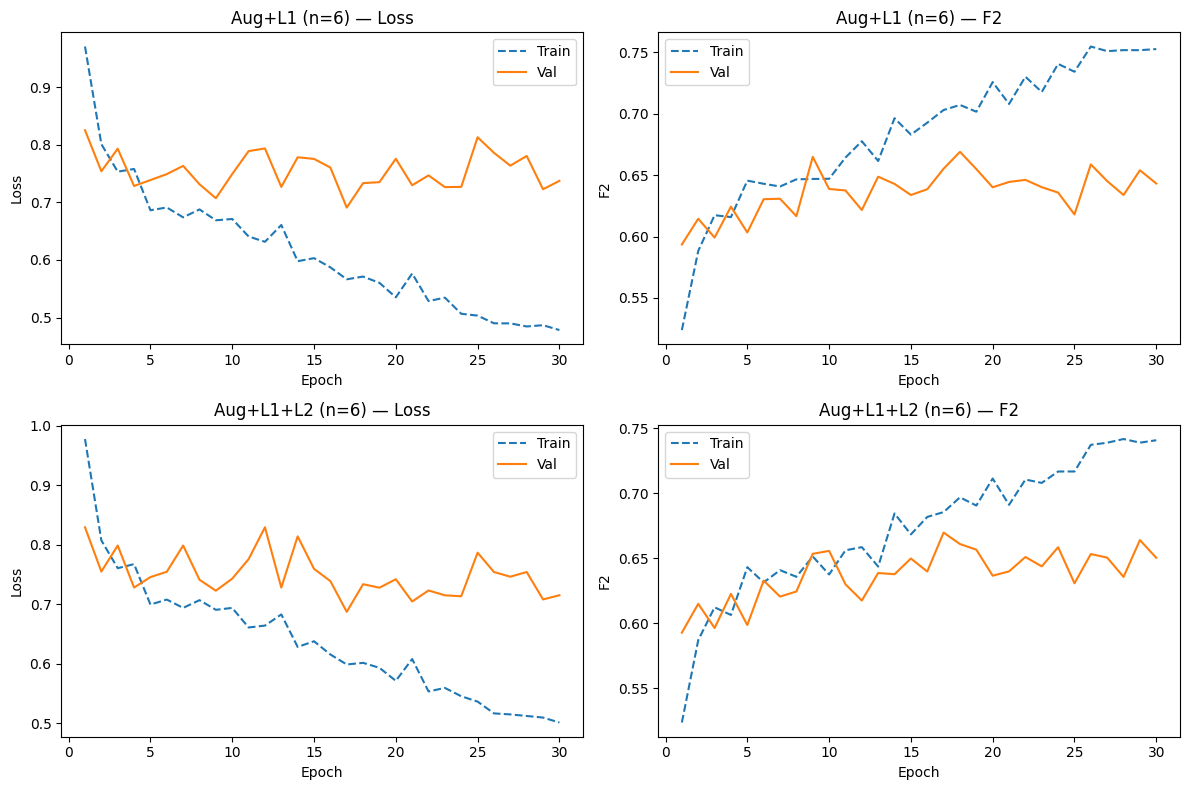

In [36]:
n_runs = len(all_results_v2)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs))
if n_runs == 1:
    axes = axes[np.newaxis, :]

for row_idx, (run_label, result) in enumerate(all_results_v2.items()):
    h      = result['history']
    epochs = range(1, len(h['train_loss']) + 1)

    ax_loss = axes[row_idx, 0]
    ax_loss.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax_loss.plot(epochs, h['val_loss'],   label='Val')
    ax_loss.set_title(f'{run_label} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_f2 = axes[row_idx, 1]
    ax_f2.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax_f2.plot(epochs, h['val_f2'],   label='Val')
    ax_f2.set_title(f'{run_label} — F2')
    ax_f2.set_xlabel('Epoch')
    ax_f2.set_ylabel('F2')
    ax_f2.legend()

plt.tight_layout()
plt.show()

## Test Set Evaluation (n=6, Cosine)

In [37]:
print(f"{'Run':<20} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test Prec':>10} | {'Test F2':>9} | {'Threshold':>9}")
print('-' * 80)

for run_label, result in all_results_v2.items():
    eval_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=UNFREEZE_BLOCKS).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    # Tune threshold on val set
    val_probs, val_labels_list = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            probs = torch.sigmoid(eval_model(images.to(device))).squeeze(1)
            val_probs.extend(probs.cpu().numpy())
            val_labels_list.extend(labels.numpy())

    thresholds  = np.arange(0.01, 0.90, 0.01)
    f2_scores   = [fbeta_score(val_labels_list, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_thresh = thresholds[np.argmax(f2_scores)]

    # Evaluate on test set
    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss, total_samples = 0.0, 0
    all_labels_t, all_probs_t  = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images     = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs    = eval_model(images)
            running_loss  += criterion_eval(outputs, labels_dev).item() * images.size(0)
            total_samples += images.size(0)
            all_probs_t.extend(torch.sigmoid(outputs).squeeze(1).cpu().numpy())
            all_labels_t.extend(labels.numpy())

    test_loss = running_loss / total_samples
    preds     = (np.array(all_probs_t) >= best_thresh).astype(int)
    test_f2   = fbeta_score(all_labels_t,  preds, beta=2, pos_label=1, zero_division=0)
    test_rec  = recall_score(all_labels_t,  preds, pos_label=1, zero_division=0)
    test_prec = precision_score(all_labels_t, preds, pos_label=1, zero_division=0)

    all_results_v2[run_label].update({
        'test_f2': test_f2, 'test_recall': test_rec, 'test_prec': test_prec,
        'test_loss': test_loss, 'threshold': best_thresh,
        'all_labels_t': all_labels_t, 'all_probs_t': all_probs_t,
    })

    print(f"{run_label:<20} | {test_loss:>9.4f} | {test_rec:>11.4f} | {test_prec:>10.4f} | {test_f2:>9.4f} | {best_thresh:>9.2f}")

Run                  | Test Loss | Test Recall |  Test Prec |   Test F2 | Threshold
--------------------------------------------------------------------------------
Aug+L1 (n=6)         |    0.7300 |      0.8070 |     0.4326 |    0.6879 |      0.51
Aug+L1+L2 (n=6)      |    0.7424 |      0.8421 |     0.3871 |    0.6818 |      0.53


## Confusion Matrix — Best Run (n=6, Cosine)

Best run: Aug+L1+L2 (n=6) (val F2 = 0.6696) | Threshold: 0.53

              precision    recall  f1-score   support

Non-Melanoma     0.9763    0.8299    0.8971      1340
    Melanoma     0.3871    0.8421    0.5304       171

    accuracy                         0.8312      1511
   macro avg     0.6817    0.8360    0.7138      1511
weighted avg     0.9096    0.8312    0.8556      1511



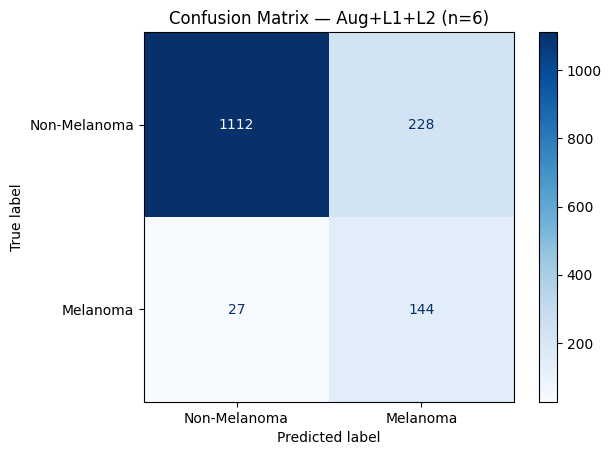

Saved to models/efficientnet_b0_aug_l1_n6_cosine_best.pth


In [38]:
best_run_v2 = max(all_results_v2, key=lambda k: all_results_v2[k]['best_val_f2'])
best_result  = all_results_v2[best_run_v2]
preds_best   = (np.array(best_result['all_probs_t']) >= best_result['threshold']).astype(int)
cm           = confusion_matrix(best_result['all_labels_t'], preds_best)

print(f'Best run: {best_run_v2} (val F2 = {best_result["best_val_f2"]:.4f}) | Threshold: {best_result["threshold"]:.2f}')
print()
print(classification_report(best_result['all_labels_t'], preds_best, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_run_v2}')
plt.show()

# Save
best_model_v2 = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=UNFREEZE_BLOCKS).to(device)
best_model_v2.load_state_dict({k: v.to(device) for k, v in best_result['best_state'].items()})
save_path = f'models/efficientnet_b0_aug_l1_n{UNFREEZE_BLOCKS}_cosine_best.pth'
torch.save(best_model_v2.state_dict(), save_path)
print(f'Saved to {save_path}')

## Overfitting Summary

In [33]:
print(f"{'Run':<12} | {'Best Val F2':>11} | {'Final Train F2':>14} | {'Final Val F2':>12} | {'F2 Gap (T-V)':>12}")
print('-' * 70)
for run_label, result in all_results.items():
    h              = result['history']
    final_train_f2 = h['train_f2'][-1]
    final_val_f2   = h['val_f2'][-1]
    gap            = final_train_f2 - final_val_f2
    print(f"{run_label:<12} | {result['best_val_f2']:>11.4f} | {final_train_f2:>14.4f} | {final_val_f2:>12.4f} | {gap:>12.4f}")

print()
print(f"{'Run':<12} | {'Final Train Loss':>15} | {'Final Val Loss':>14} | {'Loss Gap (V-T)':>14}")
print('-' * 62)
for run_label, result in all_results.items():
    h           = result['history']
    final_train = h['train_loss'][-1]
    final_val   = h['val_loss'][-1]
    gap         = final_val - final_train
    print(f"{run_label:<12} | {final_train:>15.4f} | {final_val:>14.4f} | {gap:>14.4f}")

print()
print(f"{'Run':<12} | {'Best Train Loss':>15} | {'Best Val Loss':>13} | {'Loss Gap (V-T)':>14}")
print('-' * 62)
for run_label, result in all_results.items():
    h               = result['history']
    best_train_loss = min(h['train_loss'])
    best_val_loss   = min(h['val_loss'])
    gap             = best_val_loss - best_train_loss
    print(f"{run_label:<12} | {best_train_loss:>15.4f} | {best_val_loss:>13.4f} | {gap:>14.4f}")

Run          | Best Val F2 | Final Train F2 | Final Val F2 | F2 Gap (T-V)
----------------------------------------------------------------------
Aug+L1       |      0.6410 |         0.6807 |       0.6269 |       0.0537
Aug+L1+L2    |      0.6538 |         0.6768 |       0.6292 |       0.0476

Run          | Final Train Loss | Final Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Aug+L1       |          0.6225 |         0.7478 |         0.1252
Aug+L1+L2    |          0.6280 |         0.7367 |         0.1087

Run          | Best Train Loss | Best Val Loss | Loss Gap (V-T)
--------------------------------------------------------------
Aug+L1       |          0.6073 |        0.7227 |         0.1154
Aug+L1+L2    |          0.6108 |        0.7094 |         0.0987


## Training Curves

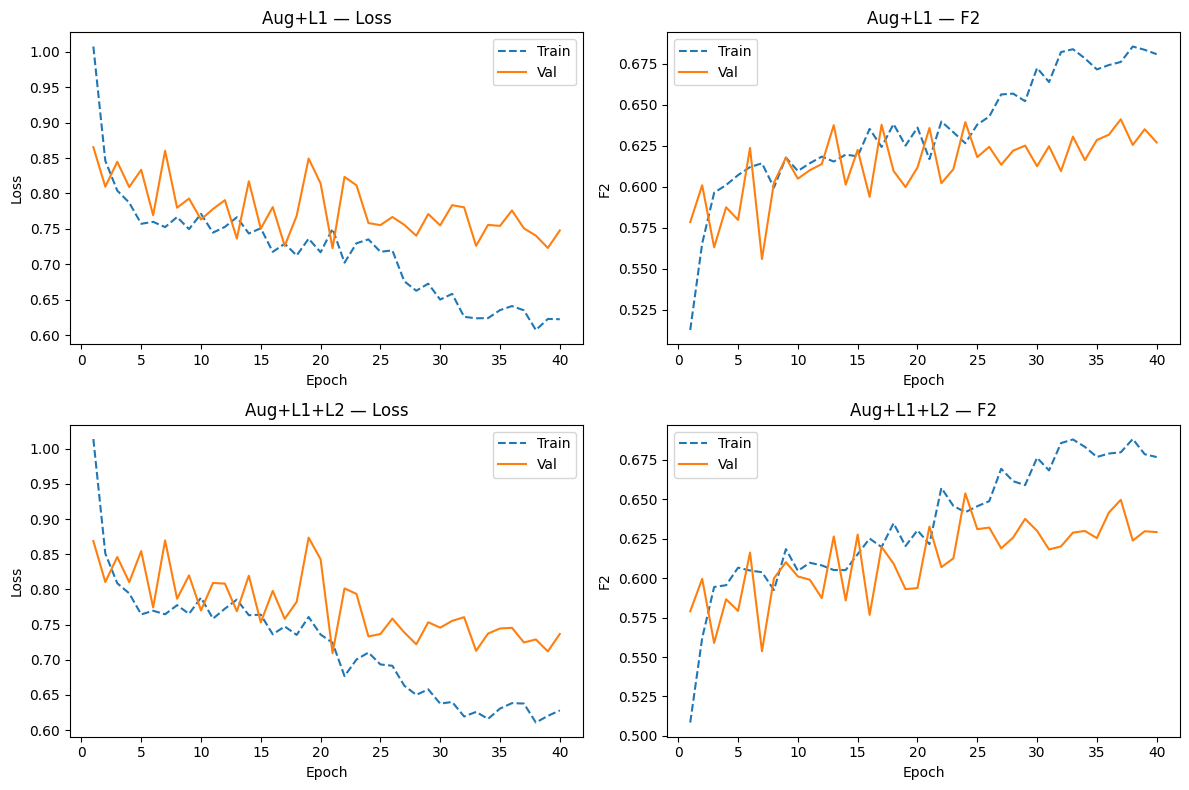

In [27]:
n_runs = len(all_results)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs))
if n_runs == 1:
    axes = axes[np.newaxis, :]

for row_idx, (run_label, result) in enumerate(all_results.items()):
    h      = result['history']
    epochs = range(1, len(h['train_loss']) + 1)

    ax_loss = axes[row_idx, 0]
    ax_loss.plot(epochs, h['train_loss'], label='Train', linestyle='--')
    ax_loss.plot(epochs, h['val_loss'],   label='Val')
    ax_loss.set_title(f'{run_label} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()

    ax_f2 = axes[row_idx, 1]
    ax_f2.plot(epochs, h['train_f2'], label='Train', linestyle='--')
    ax_f2.plot(epochs, h['val_f2'],   label='Val')
    ax_f2.set_title(f'{run_label} — F2')
    ax_f2.set_xlabel('Epoch')
    ax_f2.set_ylabel('F2')
    ax_f2.legend()

plt.tight_layout()
plt.show()

## Test Set Evaluation

In [28]:
print(f"{'Run':<12} | {'Test Loss':>9} | {'Test Recall':>11} | {'Test Prec':>10} | {'Test F2':>9} | {'Threshold':>9}")
print('-' * 72)

for run_label, result in all_results.items():
    cfg        = result['cfg']
    eval_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
    eval_model.load_state_dict({k: v.to(device) for k, v in result['best_state'].items()})
    eval_model.eval()

    # Tune threshold on val set
    val_probs, val_labels_list = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            probs = torch.sigmoid(eval_model(images.to(device))).squeeze(1)
            val_probs.extend(probs.cpu().numpy())
            val_labels_list.extend(labels.numpy())

    thresholds  = np.arange(0.01, 0.90, 0.01)
    f2_scores   = [fbeta_score(val_labels_list, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
    best_thresh = thresholds[np.argmax(f2_scores)]

    # Evaluate on test set
    criterion_eval = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    running_loss, total_samples = 0.0, 0
    all_labels_t, all_probs_t  = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images     = images.to(device)
            labels_dev = labels.float().unsqueeze(1).to(device)
            outputs    = eval_model(images)
            running_loss  += criterion_eval(outputs, labels_dev).item() * images.size(0)
            total_samples += images.size(0)
            all_probs_t.extend(torch.sigmoid(outputs).squeeze(1).cpu().numpy())
            all_labels_t.extend(labels.numpy())

    test_loss = running_loss / total_samples
    preds     = (np.array(all_probs_t) >= best_thresh).astype(int)
    test_f2   = fbeta_score(all_labels_t,  preds, beta=2, pos_label=1, zero_division=0)
    test_rec  = recall_score(all_labels_t,  preds, pos_label=1, zero_division=0)
    test_prec = precision_score(all_labels_t, preds, pos_label=1, zero_division=0)

    all_results[run_label].update({
        'test_f2': test_f2, 'test_recall': test_rec, 'test_prec': test_prec,
        'test_loss': test_loss, 'threshold': best_thresh,
        'all_labels_t': all_labels_t, 'all_probs_t': all_probs_t,
    })

    print(f"{run_label:<12} | {test_loss:>9.4f} | {test_rec:>11.4f} | {test_prec:>10.4f} | {test_f2:>9.4f} | {best_thresh:>9.2f}")

Run          | Test Loss | Test Recall |  Test Prec |   Test F2 | Threshold
------------------------------------------------------------------------
Aug+L1       |    0.8132 |      0.7953 |     0.3084 |    0.6044 |      0.53
Aug+L1+L2    |    0.7795 |      0.8070 |     0.2981 |    0.6016 |      0.54


## Save Best Run

In [29]:
best_run_label = max(all_results, key=lambda k: all_results[k]['best_val_f2'])
print(f'Best run: {best_run_label} (val F2 = {all_results[best_run_label]["best_val_f2"]:.4f})')

best_model = get_efficientnet(variant='b0', num_classes=1, unfreeze_last_n_blocks=3).to(device)
best_model.load_state_dict({k: v.to(device) for k, v in all_results[best_run_label]['best_state'].items()})

save_path = 'models/efficientnet_b0_aug_l1_best.pth'
torch.save(best_model.state_dict(), save_path)
print(f'Saved to {save_path}')

Best run: Aug+L1+L2 (val F2 = 0.6538)
Saved to models/efficientnet_b0_aug_l1_best.pth


## Confusion Matrix — Best Run

Best run: Aug+L1+L2 | Threshold: 0.54

              precision    recall  f1-score   support

Non-Melanoma     0.9685    0.7575    0.8501      1340
    Melanoma     0.2981    0.8070    0.4353       171

    accuracy                         0.7631      1511
   macro avg     0.6333    0.7822    0.6427      1511
weighted avg     0.8926    0.7631    0.8031      1511



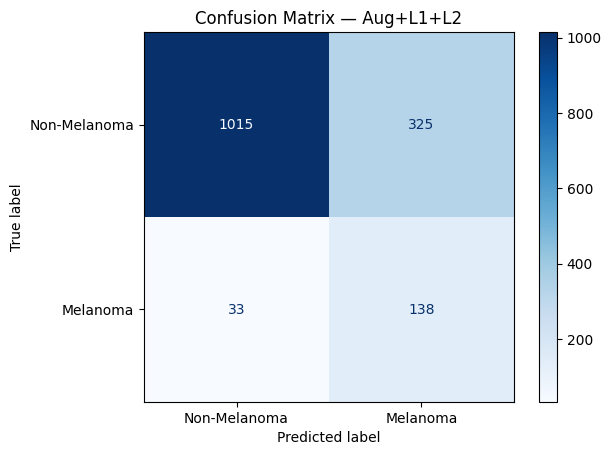

In [30]:
best_result = all_results[best_run_label]
preds_best  = (np.array(best_result['all_probs_t']) >= best_result['threshold']).astype(int)
cm          = confusion_matrix(best_result['all_labels_t'], preds_best)

print(f'Best run: {best_run_label} | Threshold: {best_result["threshold"]:.2f}')
print()
print(classification_report(best_result['all_labels_t'], preds_best, target_names=['Non-Melanoma', 'Melanoma'], digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_run_label}')
plt.show()